In [1]:
import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn  # Import neural network module
import torch.optim as optim  # Import optimization module
import src
from src.data.synthetic_data import SyntheticDataGenerator
from src.data.dataset import KineticDataset, Normalize
from src.data.data_loader import get_data_loaders
from src.models.crnn import CRNN
from src.models.loss_fn import RangeNormalizedMAE, RangeNormalizedMSE
# For one step reaction

time_hours = 1 #hours
t_end = time_hours * 3600  # seconds

data_gen_one_step = SyntheticDataGenerator(
    mechanism='one_step',
    noise_level=0.1,
    t_end=t_end,
    n_timepoints = t_end//30,  # every 30 seconds
    seed=42,
)

data_gen_latent = SyntheticDataGenerator(
    mechanism='one_step_1latent',
    noise_level=0.1,
    t_end=t_end,
    n_timepoints = t_end//30,  # every 30 seconds
    seed=42,
)

In [6]:
sampling_dim = 5
c_ranges = [
    (1, 100),  # S_1
    (1, 100),  # S_2
    (0,0),  # S_3
    (0,0) # S_out
]
k_ranges = [
    (1*1e-9, 1e7*1e-9)  # k1,
]
grid_results = data_gen_one_step.grid_search(sampling_dim = sampling_dim,
                              c_ranges=c_ranges,
                              k_ranges=k_ranges)

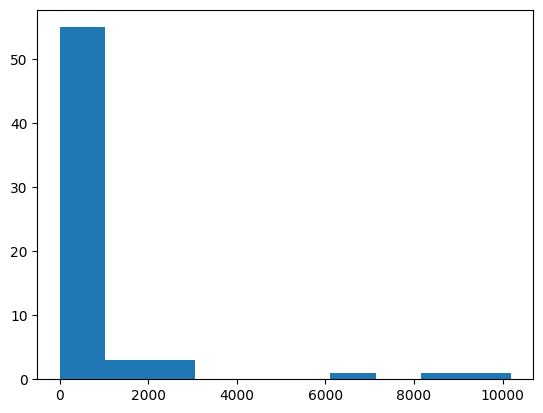


      Best parameters:
      c0: (np.float64(100.0), np.float64(100.0), 0, 0)
      k: (np.float64(0.0033333340000000003),)
      

      Best E_r: 10186.890016482377
      Worst E_r: 1.3081424590027554e-21
      

      Best restricted singular values:
      [2.99390507e+07 1.01868900e+04]

      Worst restricted singular values:
      [6.35301215e-08 1.30814246e-21]
      


In [5]:
E_dist = [res['E_restricted'] for res in grid_results]
plt.hist(E_dist, bins=10)
plt.show()


ind_best  = np.argmax(E_dist)
ind_worst = np.argmin(E_dist)

print(f'''
      Best parameters:
      c0: {grid_results[ind_best]['c0']}
      k: {grid_results[ind_best]['k']}
      ''')

print(f'''
      Best E_r: {grid_results[ind_best]['E_restricted']}
      Worst E_r: {grid_results[ind_worst]['E_restricted']}
      ''')

# print FIM and restriced FIM for best and worst cases
print(f'''
      Best restricted singular values:
      {grid_results[ind_best]['singular_values_r']}
      
      Worst restricted singular values:
      {grid_results[ind_worst]['singular_values_r']}
      ''')

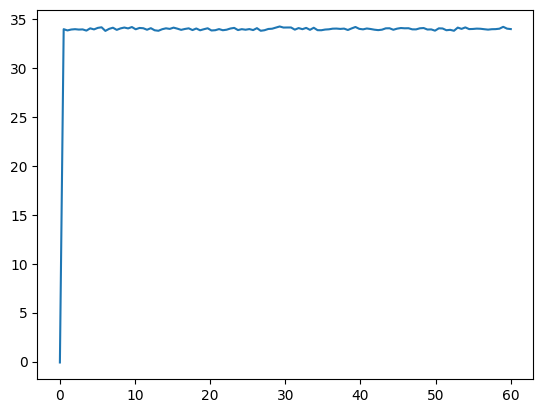

In [14]:
g = data_gen_one_step
c0_best = grid_results[np.argmax(E_dist)]['c0']
k_best = grid_results[np.argmax(E_dist)]['k']

batch = g.generate_batch( [c0_best], [k_best] )
plt.plot(batch['t']/60, batch['y'][0])

In [7]:
sampling_dim = 4
c_ranges = [
    (1, 100),  # S_1
    (1, 100),  # S_2
    (0,0), # S_3
    (0,0), # S_4
    (0,0) # S_out
]
k_ranges = [
    (1*1e-9, 1e7*1e-9)  # k1,
    ,(1e-3, 1e2)  # k2,
]
grid_results = data_gen_latent.grid_search(sampling_dim = sampling_dim,
                              c_ranges=c_ranges,
                              k_ranges=k_ranges)

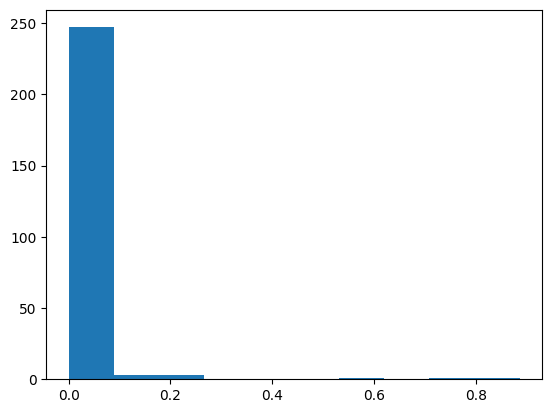


      Best parameters:
      c0: (np.float64(100.0), np.float64(100.0), 0, 0, 0)
      k: (np.float64(0.0033333340000000003), np.float64(0.001))
      

      Best E_r: 0.8856893747073138
      Worst E_r: 7.856148826839647e-24
      

      Best restricted singular values:
      [1.71519308e+08 3.98747852e+06 1.41742909e+06 7.29912555e+04
 5.97407514e+02 8.85689375e-01]

      Worst restricted singular values:
      [3.09977308e-06 8.89698491e-08 2.48297528e-12 1.19691392e-22
 1.75067106e-23 7.85614883e-24]
      


In [9]:
E_dist = [res['E_restricted'] for res in grid_results]
plt.hist(E_dist, bins=10)
plt.show()


ind_best  = np.argmax(E_dist)
ind_worst = np.argmin(E_dist)

print(f'''
      Best parameters:
      c0: {grid_results[ind_best]['c0']}
      k: {grid_results[ind_best]['k']}
      ''')

print(f'''
      Best E_r: {grid_results[ind_best]['E_restricted']}
      Worst E_r: {grid_results[ind_worst]['E_restricted']}
      ''')

# print FIM and restriced FIM for best and worst cases
print(f'''
      Best restricted singular values:
      {grid_results[ind_best]['singular_values_r']}
      
      Worst restricted singular values:
      {grid_results[ind_worst]['singular_values_r']}
      ''')